In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [ ]:
#pip install openpyxl

In [81]:
dataset = pd.read_excel("./datasets/Folds5x2_pp.xlsx")

In [82]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [83]:
dataset.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

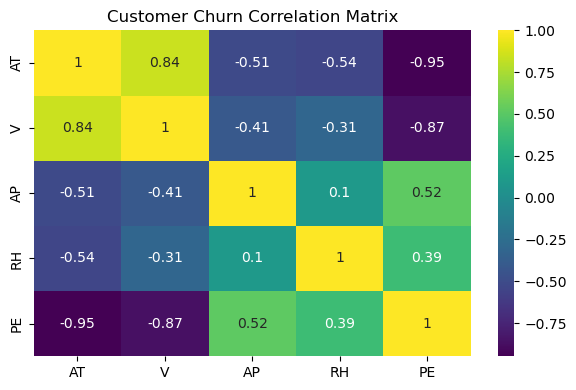

In [84]:
plt.figure(figsize=(6,4))
sns.heatmap(data=dataset.corr(), cmap='viridis', annot=True)
plt.title('Customer Churn Correlation Matrix')
plt.tight_layout()
plt.show()

In [85]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [86]:
print(X)

[[  14.96   41.76 1024.07   73.17]
 [  25.18   62.96 1020.04   59.08]
 [   5.11   39.4  1012.16   92.14]
 ...
 [  31.32   74.33 1012.92   36.48]
 [  24.48   69.45 1013.86   62.39]
 [  21.6    62.52 1017.23   67.87]]


In [87]:
print(y)

[463.26 444.37 488.56 ... 429.57 435.74 453.28]


In [88]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [89]:
#building ann
ann = tf.keras.models.Sequential()

In [90]:
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

In [91]:
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

In [92]:
ann.add(tf.keras.layers.Dense(units=1))

In [93]:
ann.compile(optimizer = 'adam', loss = 'mean_squared_error')

In [94]:
ann.fit(X_train, y_train, batch_size=32, epochs=100)

Epoch 1/100


240/240 [==============================] - 1s 2ms/step - loss: 65826.4609
Epoch 2/100
240/240 [==============================] - 0s 2ms/step - loss: 212.4410
Epoch 3/100
240/240 [==============================] - 0s 1ms/step - loss: 209.5976
Epoch 4/100
240/240 [==============================] - 0s 2ms/step - loss: 205.7768
Epoch 5/100
240/240 [==============================] - 0s 2ms/step - loss: 201.6102
Epoch 6/100
240/240 [==============================] - 0s 1ms/step - loss: 196.0356
Epoch 7/100
240/240 [==============================] - 0s 1ms/step - loss: 190.4344
Epoch 8/100
240/240 [==============================] - 0s 1ms/step - loss: 183.4015
Epoch 9/100
240/240 [==============================] - 0s 1ms/step - loss: 176.3673
Epoch 10/100
240/240 [==============================] - 0s 1ms/step - loss: 168.3883
Epoch 11/100
240/240 [==============================] - 0s 2ms/step - loss: 159.7693
Epoch 12/100
240/240 [==============================] - 0s 1ms/step - loss: 150.9905

In [98]:
y_pred = ann.predict(X_test)
np.set_printoptions(precision=2)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

60/60 [==============================] - 0s 1ms/step
[[429.24 431.23]
 [460.21 460.01]
 [463.7  461.14]
 ...
 [470.92 473.26]
 [437.83 438.  ]
 [456.98 463.28]]


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R-squared: {r2:.2f}")


Mean Squared Error: 28.98
Mean Absolute Error: 4.23
R-squared: 0.90
